## **SUMMARY**
This script is used to preprocess census data and footprint data to be merged to create a footprint-level building inventory.

### **REQUIRED INPUTS**
- State / County FIPS codes (entered in notebook)
- Building footprints GEOJSON file (local footprint dataset and/or USA Structures dataset) 


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# Relevant python functions
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium 
import os
import sys

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_preprocessing as pre 
import functions_general as fxns 

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# Set state, state fips, and county for downloading census data 
state = 'California'
state_fips = '06'
county = 'Alameda'
county_fips = '001'

## **Download and Create City-Specific Census Boundary Files**

In [4]:
# Download 2010 and 2020 place, block, and tract files for state/county of interest
# These functions save files to ./Input_Data/Census folder
# NOTE: Retrieving census data can take ~1 minute. This data is required for the point to footprint attribution process

pre.download_2010_census_boundaries(state, state_fips, county, county_fips)

pre.download_2020_census_boundaries(state, state_fips, county, county_fips)

/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding ce

In [5]:
##### LOAD AND PROCESS 2020 CENSUS DATA #####

# Load data 
tracts_gdf = gpd.read_file(f'./Input_Data/Census/Census2020/{state}/{county}/tl_2020_{state_fips}{county_fips}_tract20.shp')
blocks_gdf = gpd.read_file(f'./Input_Data/Census/Census2020/{state}/{county}/tl_2020_{state_fips}{county_fips}_tabblock20.shp')
places_gdf = gpd.read_file(f'./Input_Data/Census/Census2020/{state}//tl_2020_{state_fips}_place20.shp')

# Convert data to CRS that is best for local calculations
tracts_gdf = tracts_gdf.to_crs(crs_main)
blocks_gdf = blocks_gdf.to_crs(crs_main)
places_gdf = places_gdf.to_crs(crs_main)

# Filter places to get Hayward boundary (this is used as definition of study area)
hayward_census = places_gdf[places_gdf['NAME20']=='Hayward']

# Rename tract ID to match block and place
tracts_gdf = tracts_gdf.rename(columns={'GEOID': 'GEOID20'})


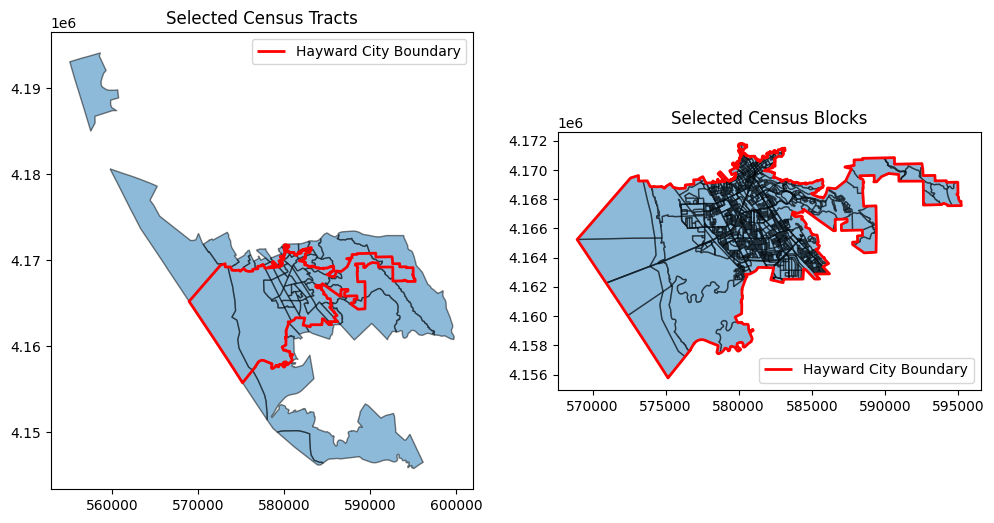

In [6]:
##### FIND AND SAVE CENSUS TRACTS AND BLOCKS THAT ARE WITHIN HAYWARD, CA #####
censustracts_city, censusblocks_city = pre.find_city_tracts_and_blocks(tracts_gdf, blocks_gdf, hayward_census, 'GEOID20')

# Plot to visualize results 
fig, ax = plt.subplots(1,2,figsize=(12, 12))
censustracts_city.plot(ax=ax[0], color='tab:blue', alpha=0.5, edgecolor='k')
hayward_census.boundary.plot(ax=ax[0], color='red', linewidth=2, label='Hayward City Boundary')
censusblocks_city.plot(ax=ax[1], color='tab:blue', alpha=0.5, edgecolor='k')
hayward_census.boundary.plot(ax=ax[1], color='red', linewidth=2, label='Hayward City Boundary')
ax[0].legend(loc='upper right')
ax[1].legend(loc = 'lower right')
ax[0].set_title('Selected Census Tracts')
ax[1].set_title('Selected Census Blocks')

# Export tracts and blocks associated with the selected city for future use 
hayward_census.to_file('./Input_Data/Census/Census2020/Hayward_census.geojson', driver = "GeoJSON")
censustracts_city.to_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson', driver = "GeoJSON")
censusblocks_city.to_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson', driver = "GeoJSON")

## **Load and Filter Footprint Data: USA Structures Footprints**

In [7]:
##### LOAD FOOTPRINT DATA DOWNLOADED FROM HAYWARD GIS AND CONVERT TO APPROPRIATE CRS #####
footprints = gpd.read_file('./Input_Data/National/BRAILS_nsi_usastr.geojson')
footprints = footprints.to_crs(epsg=crs_main)

#### KEEP ONLY DATA ASSOCIATED WITH FOOTPRINT (NOT ALL OF BRAILS NSI DATA) ####
footprints = footprints[['BuildingHeight','geometry']]

##### DROP ALL FOOTPRINTS SMALLER THAN 450ft2 - FOLLOWING USASTR MINIMUM SIZE LIMIT #####
footprints['area_ft2'] = footprints['geometry'].area * 10.7639  # 1 square meter = 10.7639 square feet
footprints_450 = footprints[footprints['area_ft2'] >= 450]
print(len(footprints) - len(footprints_450), 'footprints dropped due to size limit')
print(len(footprints_450), 'footprints remaining')

##### DISCARD DUPLICATE FOOTPRINTS #####
duplicate_geometries = footprints_450[footprints_450.duplicated(subset='geometry')]
footprints_450 = footprints_450.drop_duplicates(subset='geometry', keep='first')


##### ASSIGN CENSUS INFORMATION TO FOOTPRINTS -- USING 2020 CENSUS BLOCKS #####
# Load Census blocks and tracts 
city_blocks = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')
city_tracts = gpd.read_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson')

# Assign Census information to footprints based on centoroid
city_footprints = pre.assign_footprint_block_and_track(footprints_450, city_tracts, city_blocks, 'GEOID20')

75 footprints dropped due to size limit
36583 footprints remaining


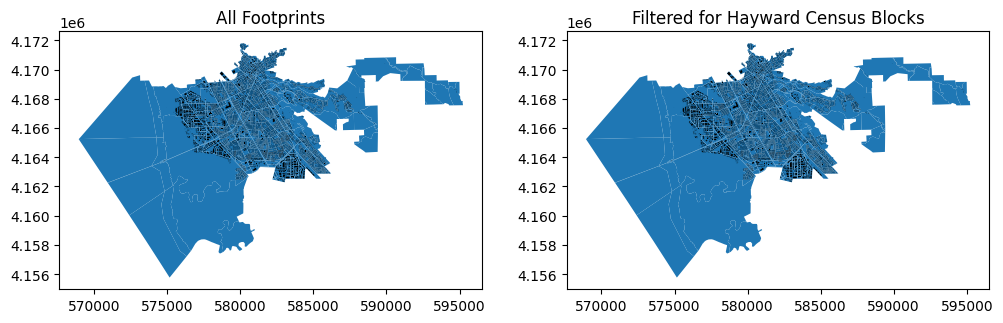

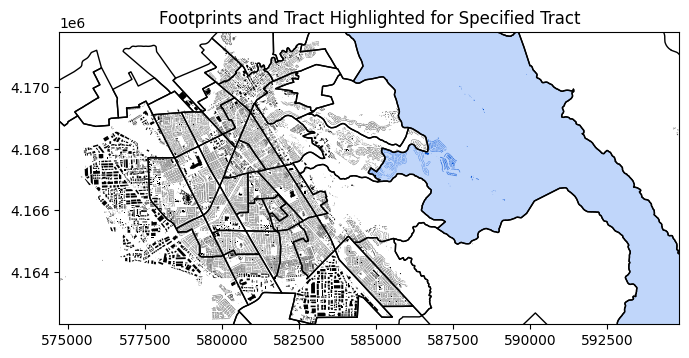

In [8]:
## PLOT TO ASSESS ACCURACY OF CENSUS ASSIGNMENT

# Plot to assess merge 
fig, ax = plt.subplots(1,2, figsize = (12, 12))
city_blocks.plot(ax=ax[0])
footprints_450.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Footprints')
city_blocks.plot(ax=ax[1])
city_footprints.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Filtered for Hayward Census Blocks')

# Plot example tract to check accuracy 
tract = city_tracts['GEOID20'][4]  # Select example census block 
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
city_tracts.boundary.plot(ax=ax, color='black', linewidth=1)
city_footprints.plot(ax=ax, color='black')
city_tracts[city_tracts["GEOID20"] == tract].plot(ax=ax, color='#c0d6fa')
city_footprints[city_footprints["CensusTract"] == tract].plot(ax=ax, color='#0050d4')
xmin, ymin, xmax, ymax = city_footprints.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('Footprints and Tract Highlighted for Specified Tract')
plt.show()

In [9]:
##### EXPLORE AND REMOVE OVERLAPPING FOOTPRINTS #####

# Set overlap limit: If two footprints are overlapping by MORE than the ratio
# specified in overlap_limit, the overlapping footprints will be output in the overalp dataframe and plotted
# If the goal is to have no overlapping footprints, set overlap_limit = 'no_overlap'
overlap_limit = 0.7

# Specify column to be used in overlap function (will be deleted later)
city_footprints['Overlap_ID'] = range(len(city_footprints))

# Find footprints that are more than 70% overlapped with another footprint 
overlap = pre.find_overlapping_ftpt(city_footprints.copy(), overlap_limit)

# If there are overallping footprints, display plot 
## NOTE: No overlap for USA Structures in Hayward. If there are overlapping footprints, see code to handle that above in Hayward Footprint Source 
if len(overlap): 
    m = folium.Map(location=[overlap.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, overlap.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)
    folium.GeoJson(overlap.copy().to_crs(crs_plot), color = 'red').add_to(m)
    display(m)
else: 
    # Remove additional ID column
    city_footprints = city_footprints.drop(columns='Overlap_ID')
    print('No Signficiantly Overlapping Footprints Found')

No Signficiantly Overlapping Footprints Found


In [10]:
##### RENAME APPROPRIATE COLUMNS AND SAVE FILE #####

# Rename columns to standard format 
city_footprints = city_footprints.rename(columns={'area_ft2':'FootprintArea', 
                                                'BuildingHeight':'FootprintHeight'})


# Ensure correct data type 
city_footprints['FootprintArea'] = pd.to_numeric(city_footprints['FootprintArea'], errors='coerce')
city_footprints['FootprintHeight'] = pd.to_numeric(city_footprints['FootprintHeight'], errors='coerce')


# Save footprints with ID
city_footprints['FootprintID'] = range(len(city_footprints))
if not os.path.exists('./Input_Data/ProcessedFootprints/'):
    os.makedirs('./Input_Data/ProcessedFootprints/')
fxns.gdf_to_json(city_footprints, './Input_Data/ProcessedFootprints/USAStructures_Footprints.json')

JSON File Saved
